In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import datasets, layers, models
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)

import seaborn as sns

plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Times New Roman", "Times", "DejaVu Serif"]
plt.rcParams["font.size"] = 15
plt.rcParams["figure.dpi"] = 600
plt.rcParams["savefig.dpi"] = 600

In [ ]:
(x_train, y_train), (x_test, y_test) = datasets.cifar10.load_data()

print("Training data shape:", x_train.shape)
print("Training labels shape:", y_train.shape)

print("Testing data shape:", x_test.shape)
print("Testing labels shape:", y_test.shape)

Training data shape: (50000, 32, 32, 3)
Training labels shape: (50000, 1)
Testing data shape: (10000, 32, 32, 3)
Testing labels shape: (10000, 1)


In [ ]:
class_names = [
    'airplane',
    'automobile',
    'bird',
    'cat',
    'deer',
    'dog',
    'frog',
    'horse',
    'ship',
    'truck'
]

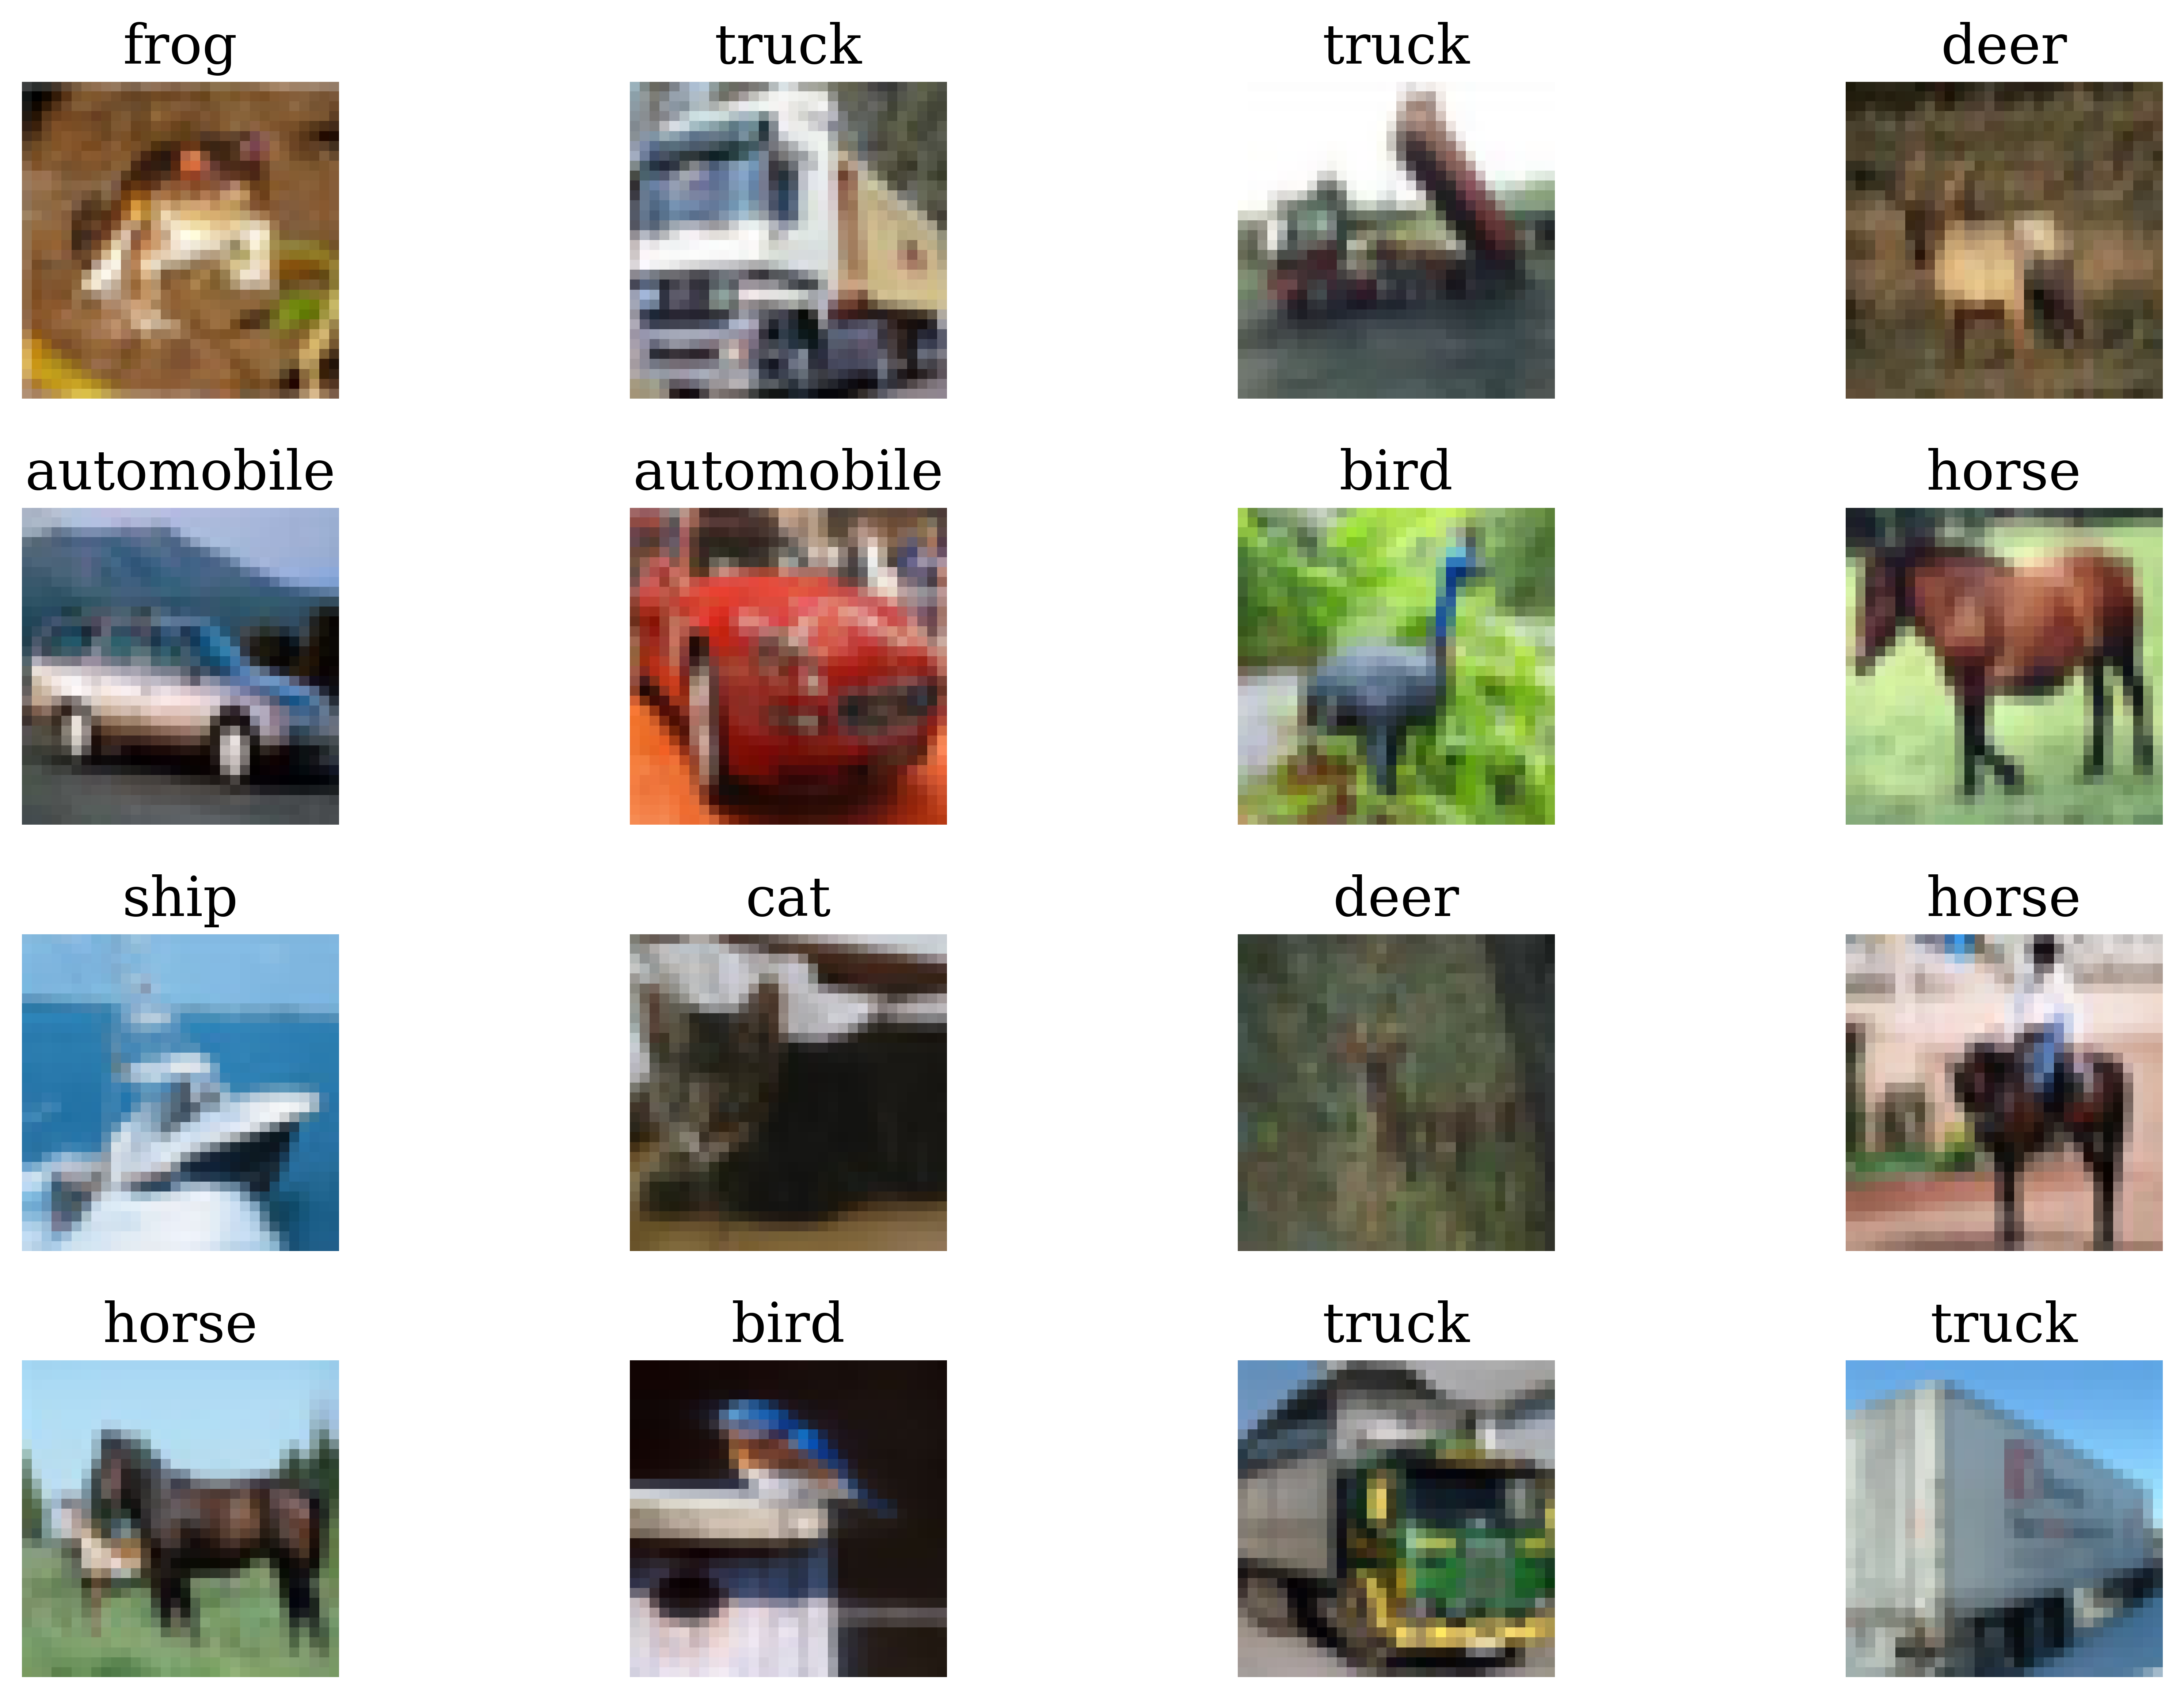

In [ ]:
plt.figure(figsize=(12, 8))

for i in range(16):
    plt.subplot(4, 4, i + 1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")

plt.tight_layout()
plt.savefig(
    "sample_images.eps",
    dpi=600,
    bbox_inches="tight"
)
plt.show()

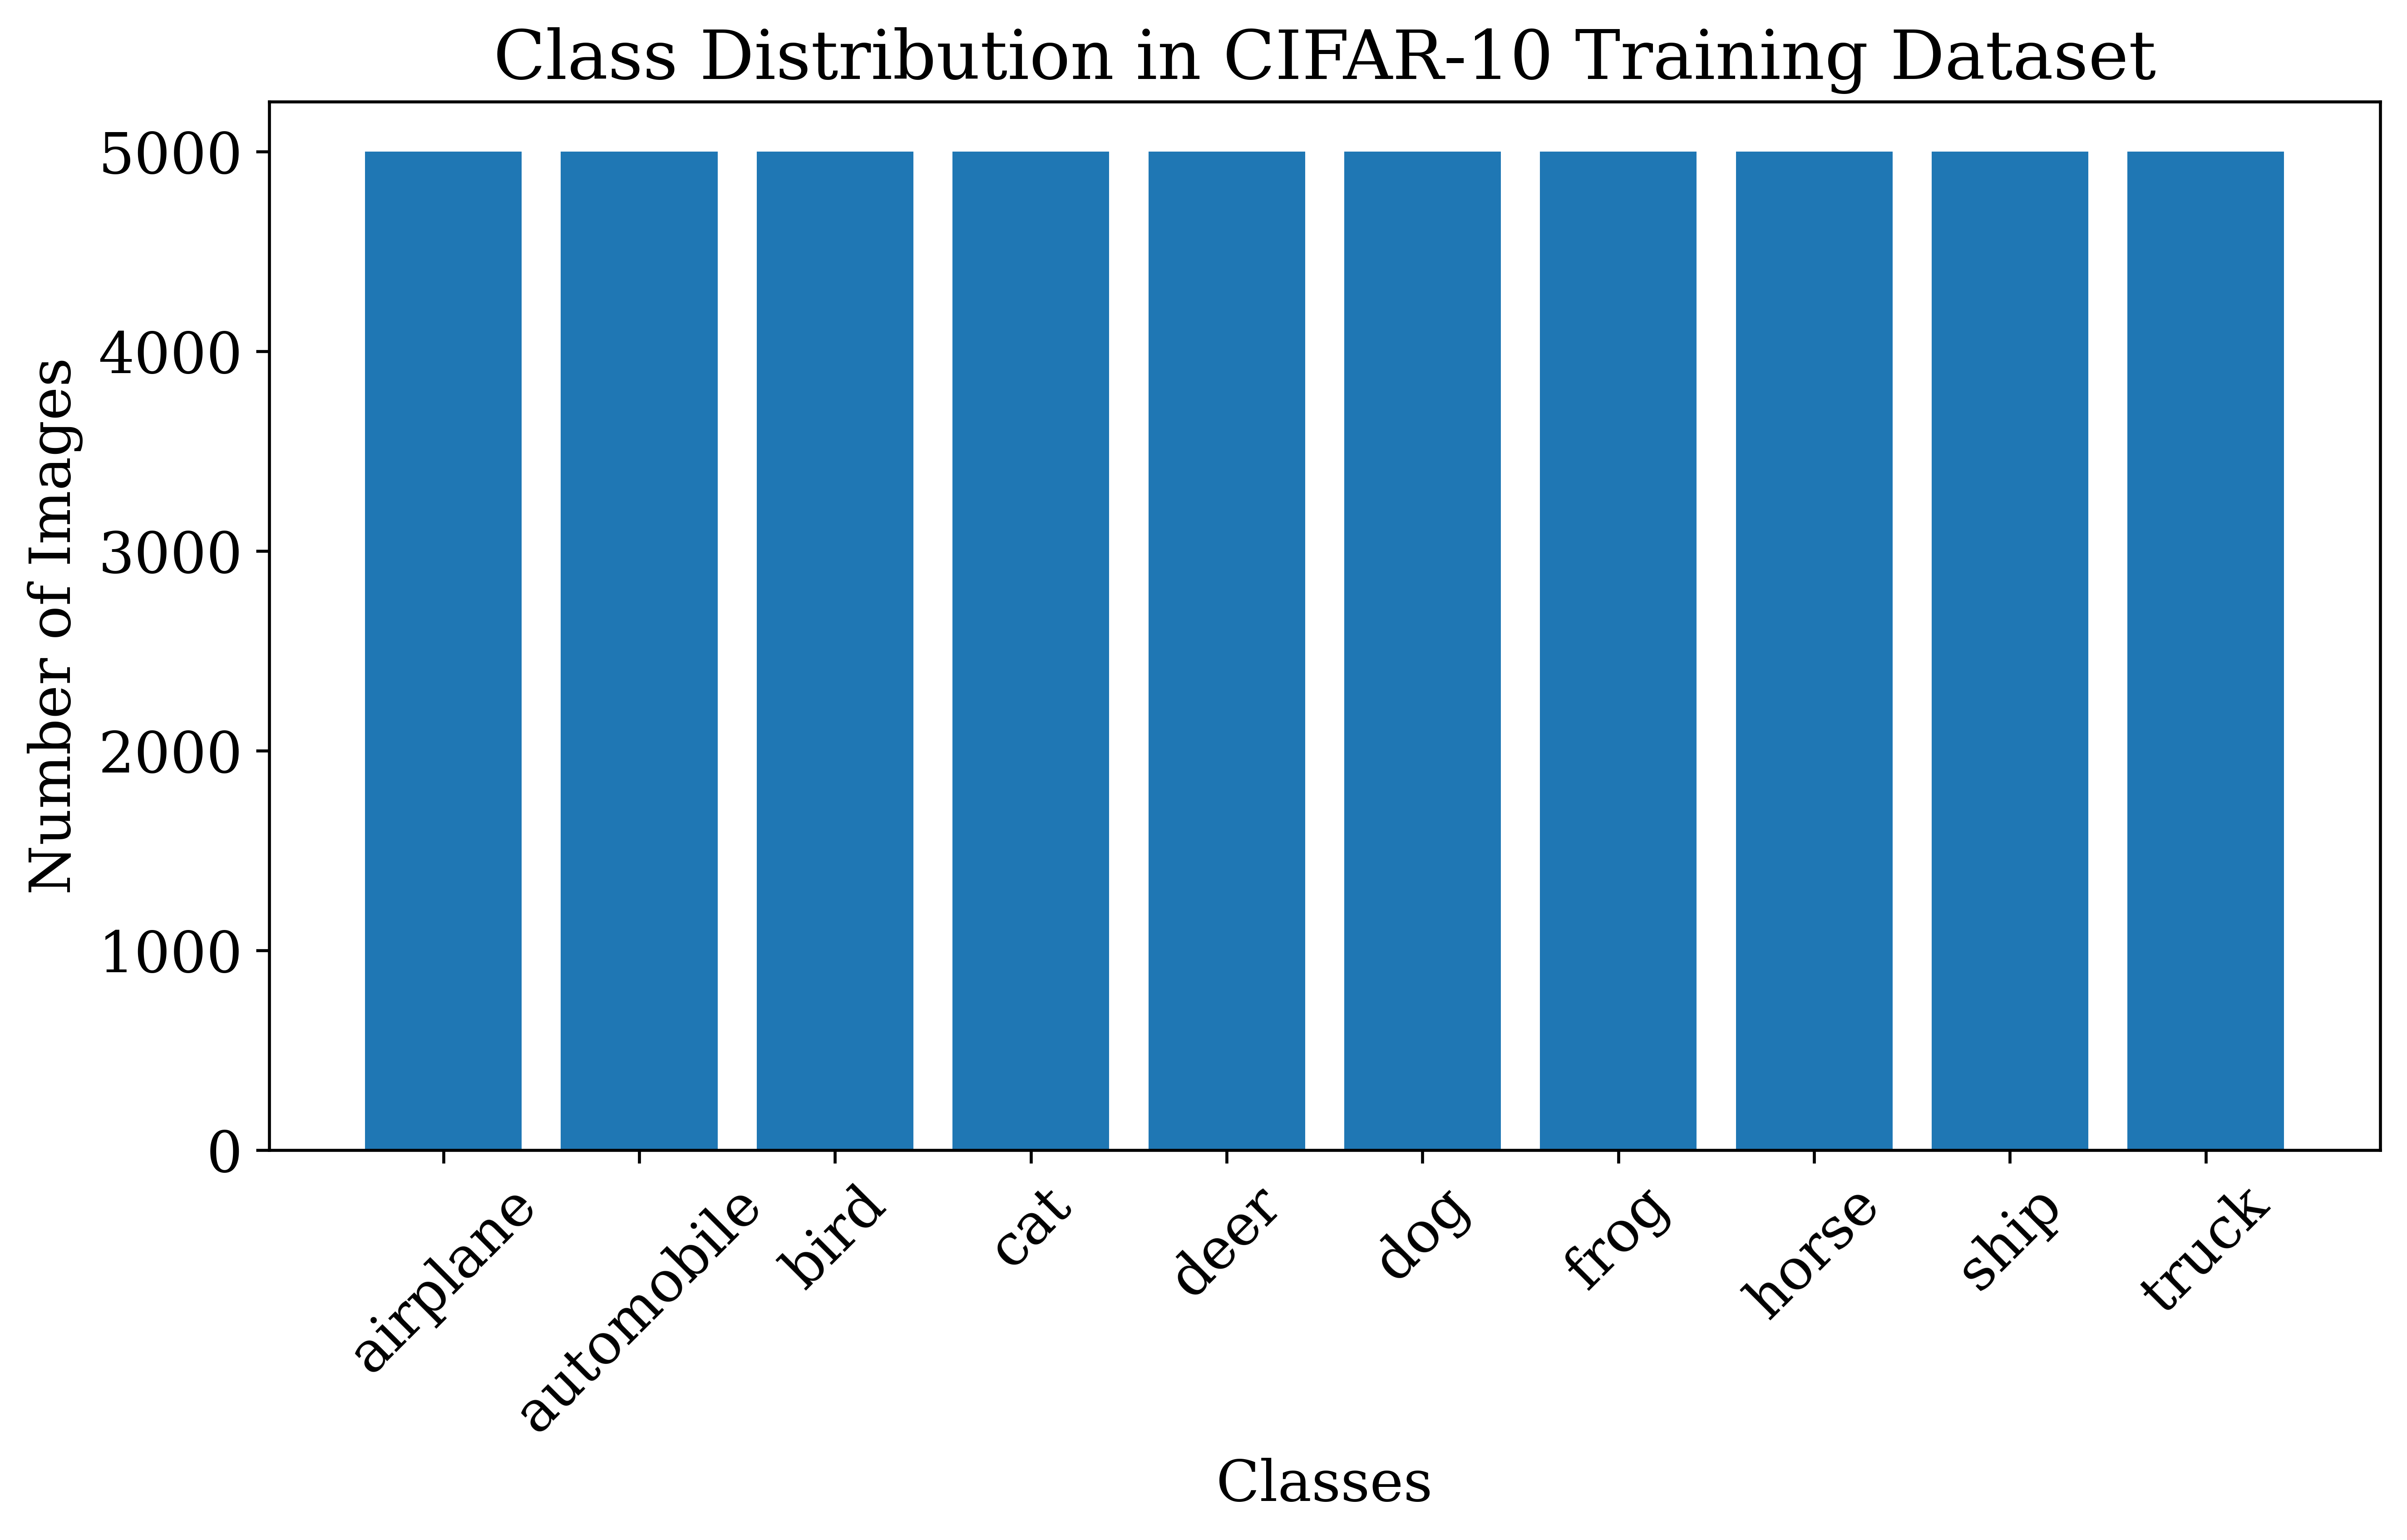

In [ ]:
y_train_flat = y_train.flatten()

class_counts = np.bincount(y_train_flat)

plt.figure(figsize=(10, 5))

plt.bar(class_names, class_counts)

plt.title("Class Distribution in CIFAR-10 Training Dataset")
plt.xlabel("Classes")
plt.ylabel("Number of Images")

plt.xticks(rotation=45)
plt.savefig(
    "class_distribution.eps",
    dpi=600,
    bbox_inches="tight"
)
plt.show()

In [ ]:
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

In [ ]:
model = tf.keras.Sequential([

    tf.keras.Input(shape=(32, 32, 3)),

    layers.Conv2D(
        filters=32,
        kernel_size=(3, 3),
        activation='relu',
        padding='same'
    ),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Conv2D(
        filters=64,
        kernel_size=(3, 3),
        activation='relu',
        padding='same'
    ),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Conv2D(
        filters=128,
        kernel_size=(3, 3),
        activation='relu',
        padding='same'
    ),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 356,810 (1.36 MB)

 Trainable params: 356,810 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,070,432 (4.08 MB)

 Trainable params: 356,810 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 713,622 (2.72 MB)

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    x_train,
    y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 121s 167ms/step - accuracy: 0.3668 - loss: 1.7132 - val_accuracy: 0.5192 - val_loss: 1.3061
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 140s 164ms/step - accuracy: 0.5150 - loss: 1.3426 - val_accuracy: 0.5936 - val_loss: 1.1554
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 139s 160ms/step - accuracy: 0.5910 - loss: 1.1554 - val_accuracy: 0.6594 - val_loss: 0.9555
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 113s 160ms/step - accuracy: 0.6372 - loss: 1.0283 - val_accuracy: 0.6932 - val_loss: 0.8682
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 116s 164ms/step - accuracy: 0.6775 - loss: 0.9255 - val_accuracy: 0.7170 - val_loss: 0.8289
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 114s 162ms/step - accuracy: 0.7003 - loss: 0.8644 - val_accuracy: 0.7300 - val_loss: 0.7926
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 143s 164ms/step - accuracy: 0.7214 - loss: 0.7982 - val_accuracy: 0.7308 - val_loss: 0.7638
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 117s 167ms/step - accuracy: 0.7376 -

In [ ]:
test_loss, test_accuracy = model.evaluate(
    x_test,
    y_test,
    verbose=0
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

Test Loss: 0.8891867995262146
Test Accuracy: 0.743399977684021


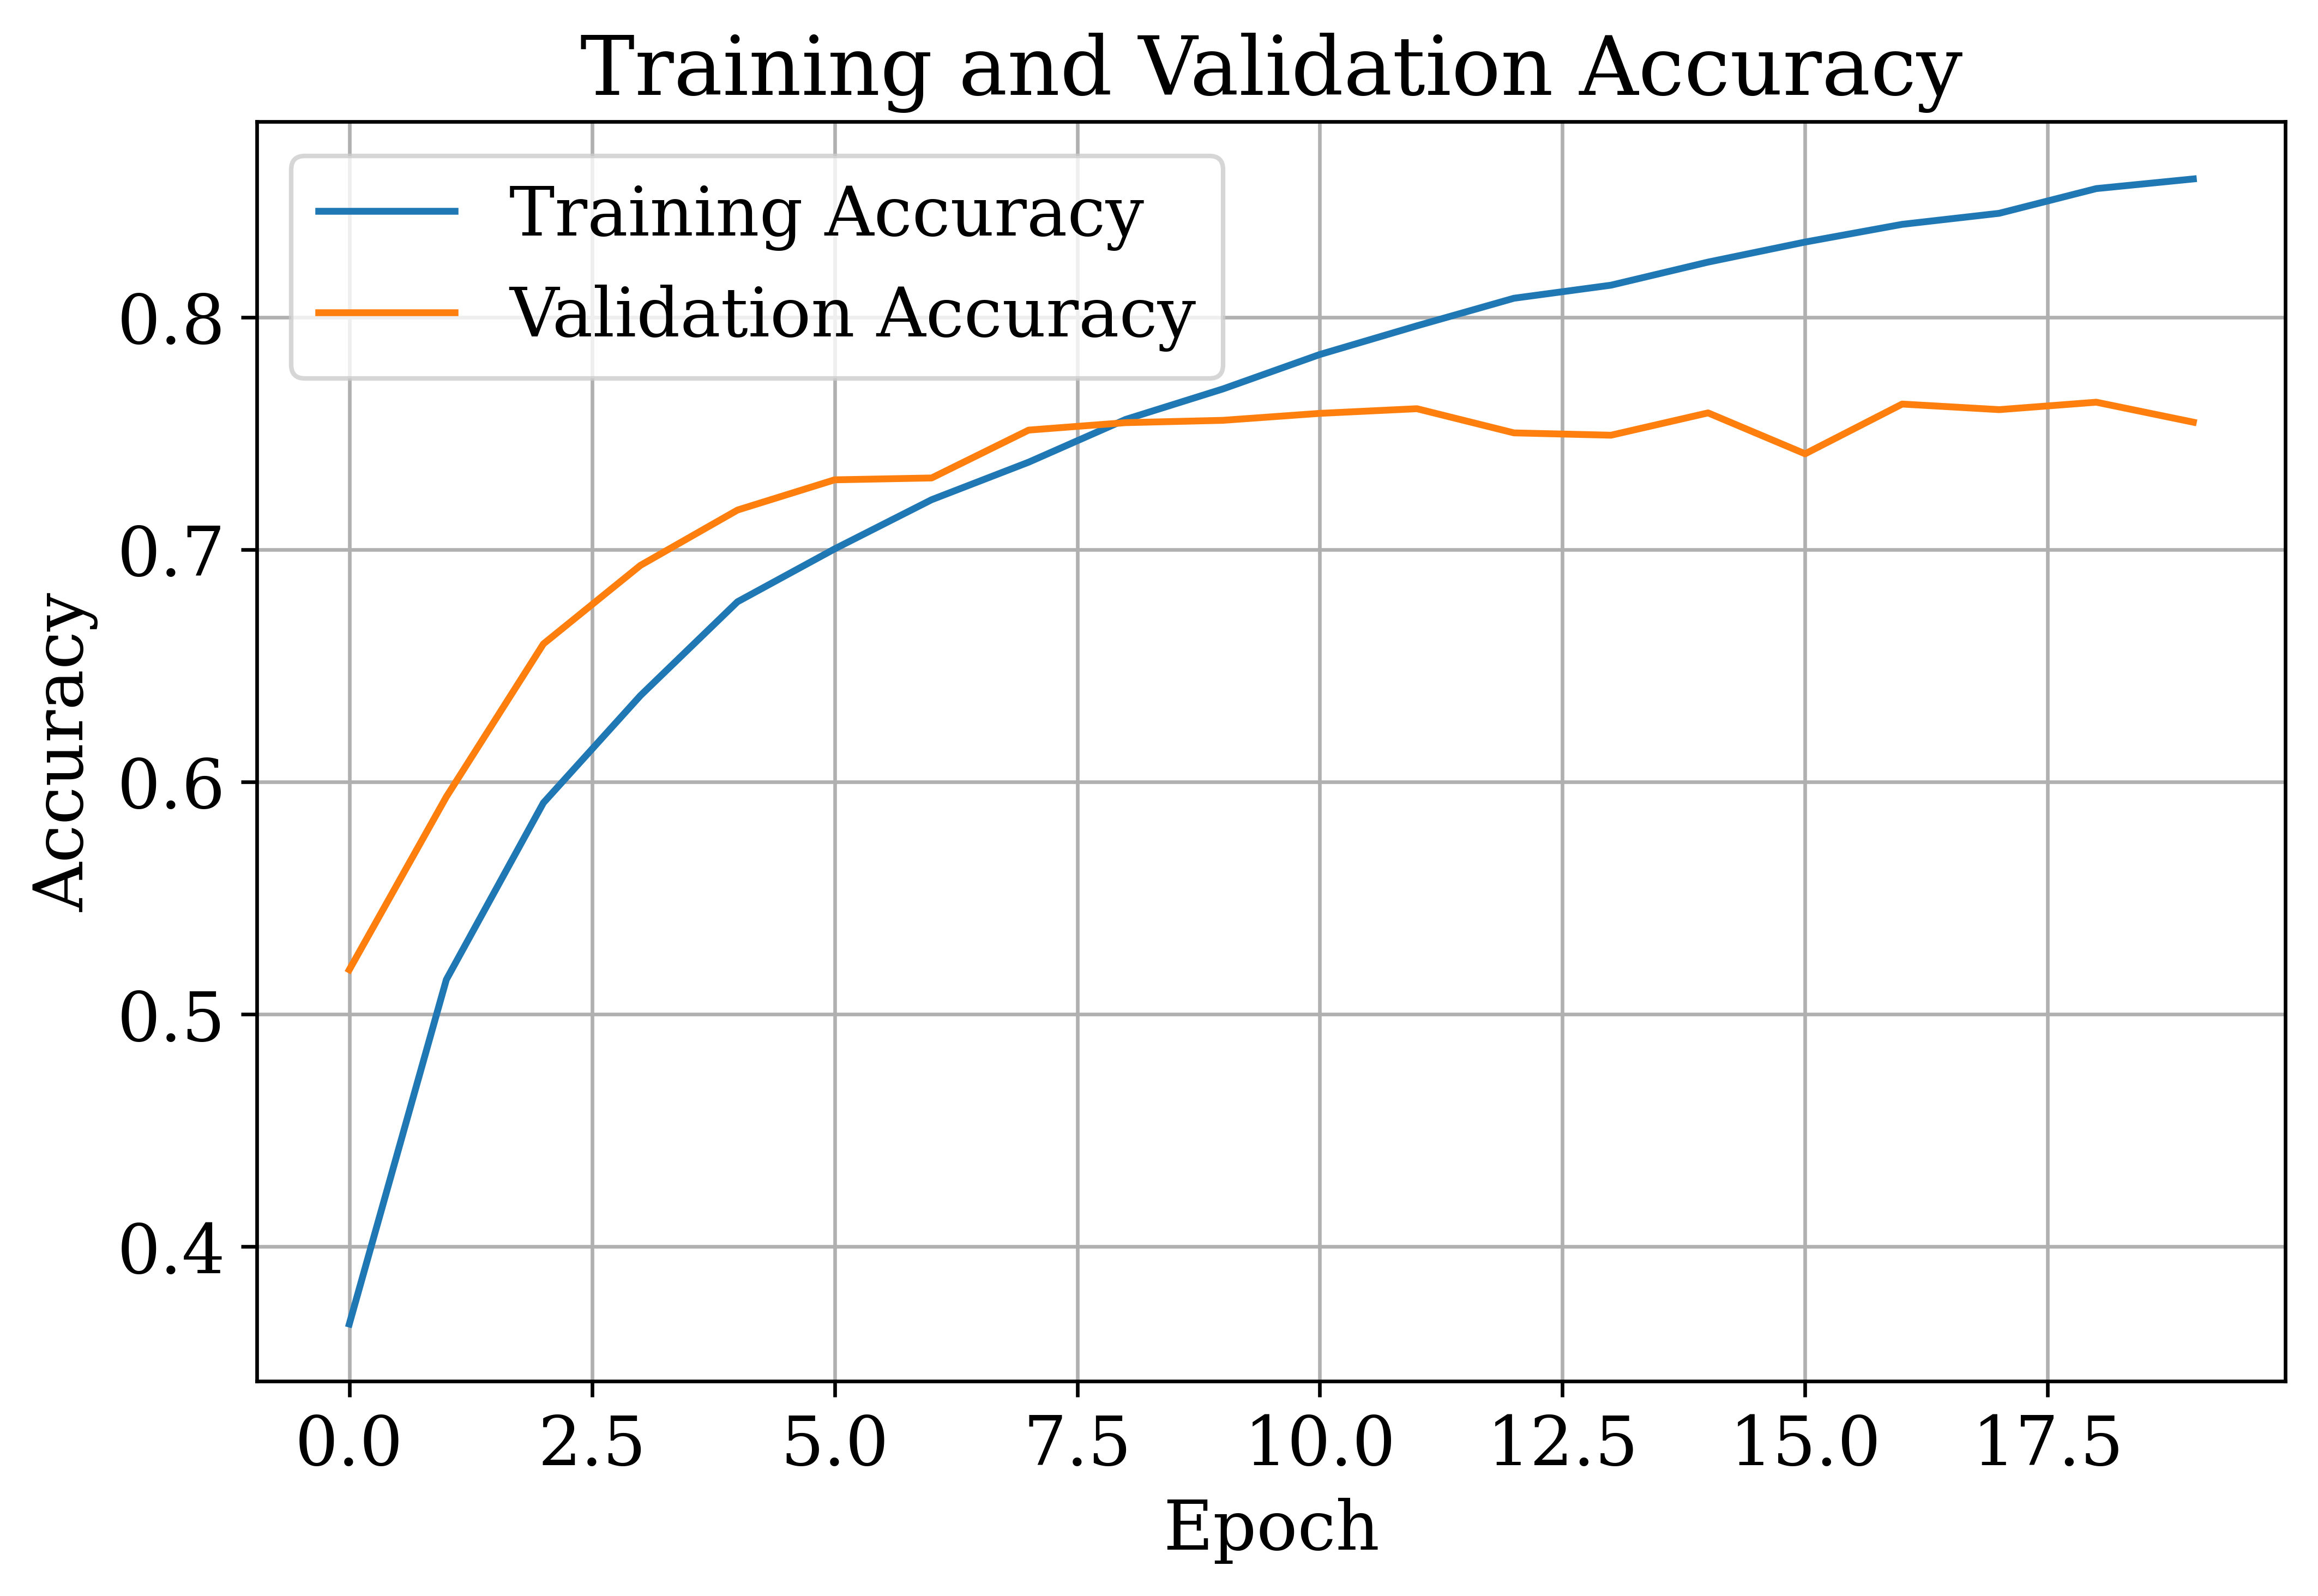

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend()
plt.grid()
plt.savefig(
    "training_and_Validation_acc.eps",
    dpi=600,
    bbox_inches="tight"
)
plt.show()

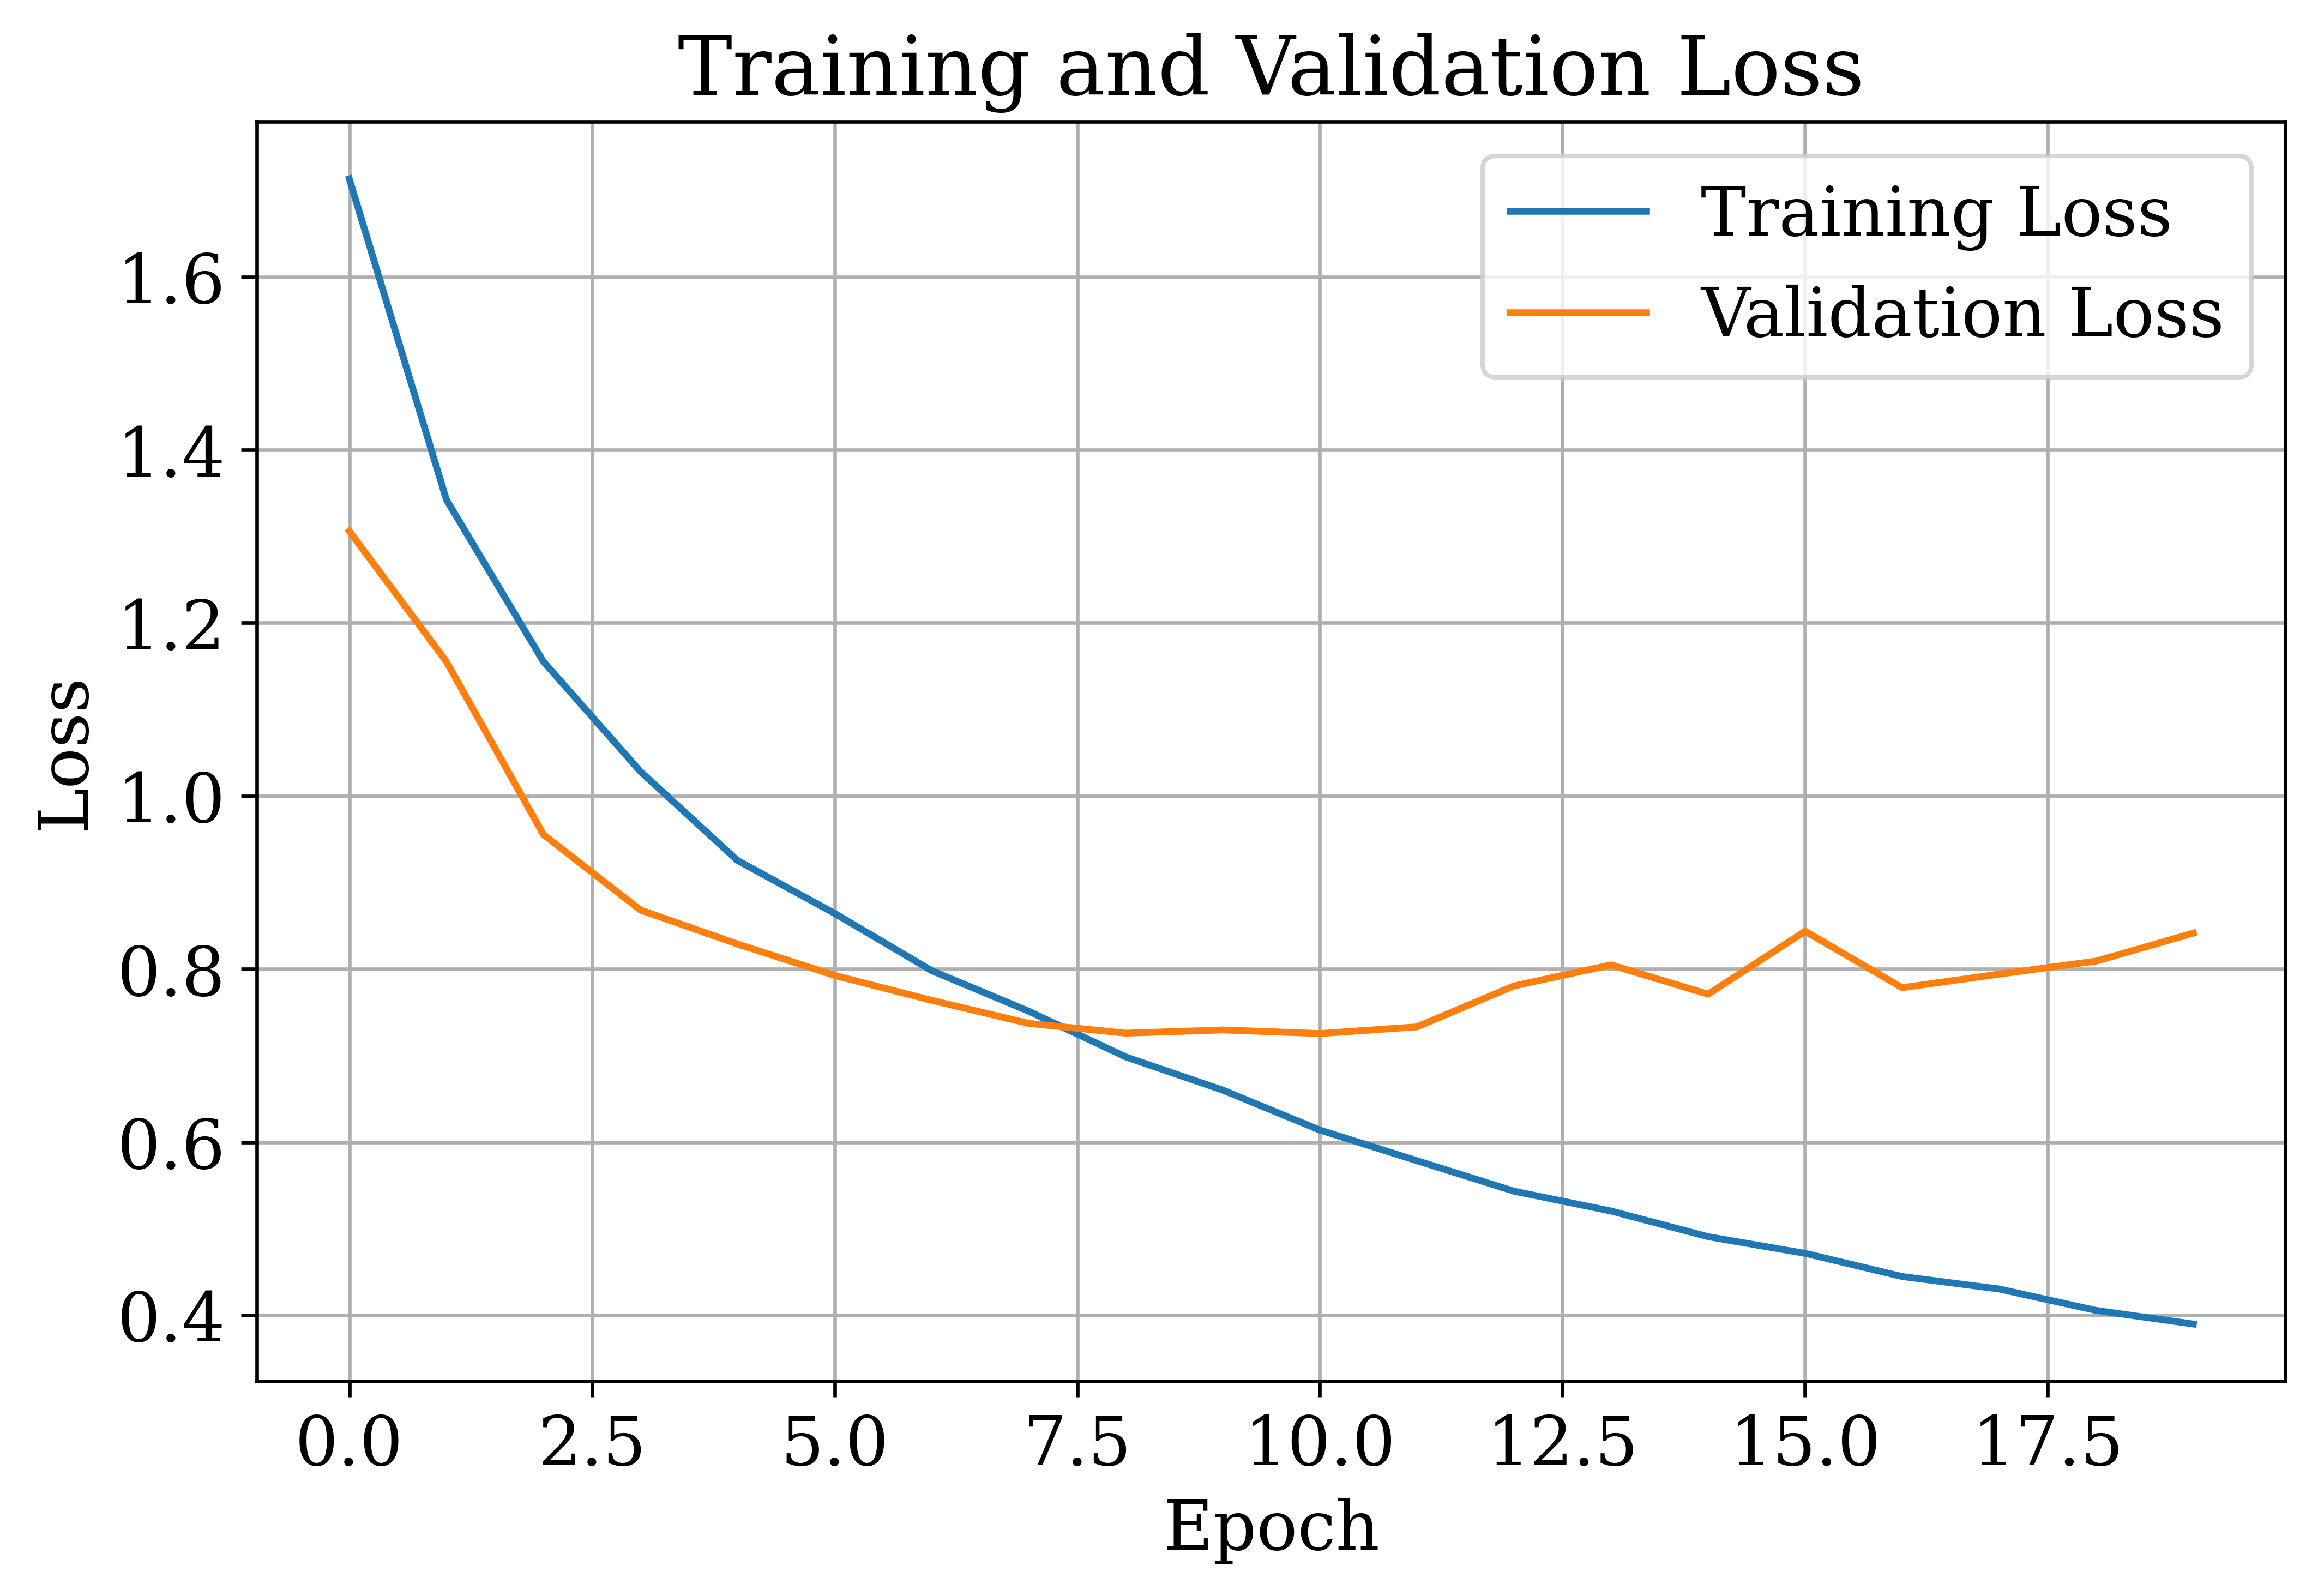

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend()
plt.grid()
plt.savefig(
    "Training_and_Validation_Loss.eps",
    dpi=600,
    bbox_inches="tight"
)
plt.show()

In [ ]:
y_pred_prob = model.predict(x_test)

y_pred = np.argmax(y_pred_prob, axis=1)

y_true = y_test.flatten()

313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 27ms/step


In [ ]:
accuracy = np.mean(y_pred == y_true)

precision = precision_score(
    y_true,
    y_pred,
    average='weighted'
)

recall = recall_score(
    y_true,
    y_pred,
    average='weighted'
)

f1 = f1_score(
    y_true,
    y_pred,
    average='weighted'
)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.7434
Precision: 0.748520017076481
Recall   : 0.7434
F1 Score : 0.7440070736641644


In [ ]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

    airplane       0.74      0.83      0.78      1000
  automobile       0.85      0.86      0.85      1000
        bird       0.70      0.62      0.66      1000
         cat       0.56      0.51      0.54      1000
        deer       0.65      0.71      0.68      1000
         dog       0.59      0.73      0.65      1000
        frog       0.84      0.77      0.80      1000
       horse       0.79      0.79      0.79      1000
        ship       0.90      0.81      0.85      1000
       truck       0.87      0.80      0.83      1000

    accuracy                           0.74     10000
   macro avg       0.75      0.74      0.74     10000
weighted avg       0.75      0.74      0.74     10000



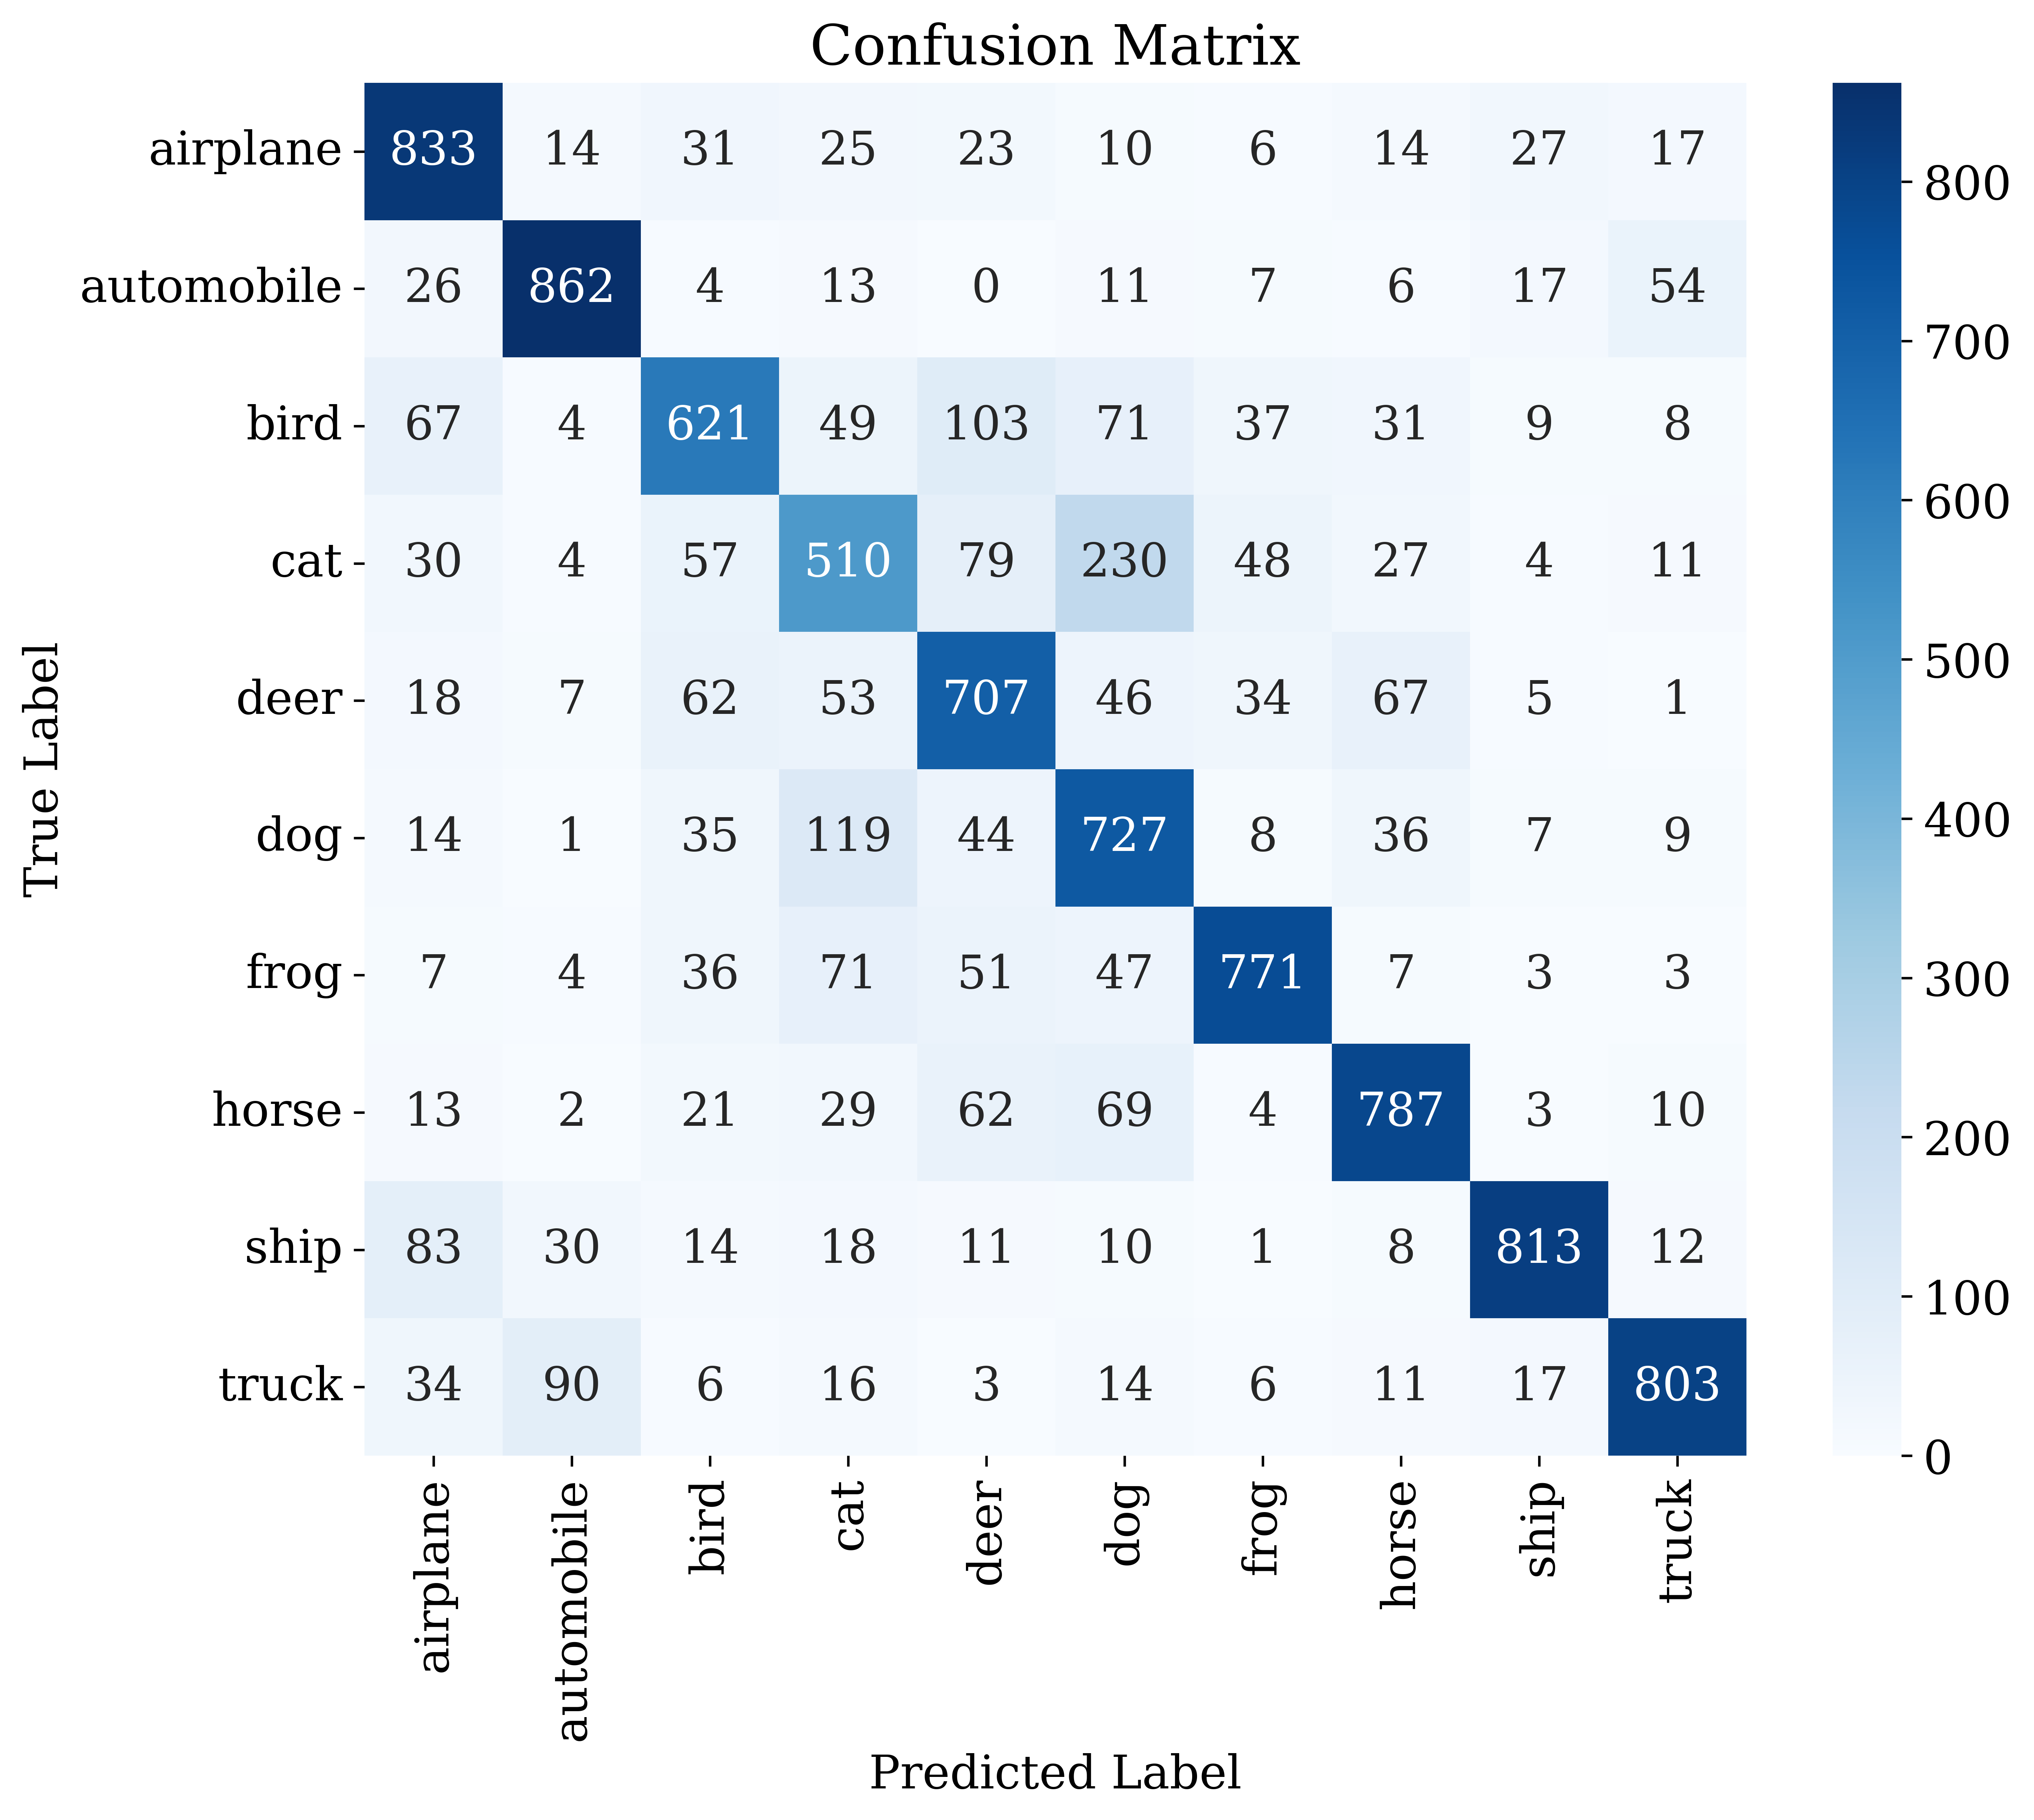

In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    cmap='Blues',
    fmt='d',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.savefig(
    "confusion_matrix.eps",
    dpi=600,
    bbox_inches="tight"
)
plt.show()

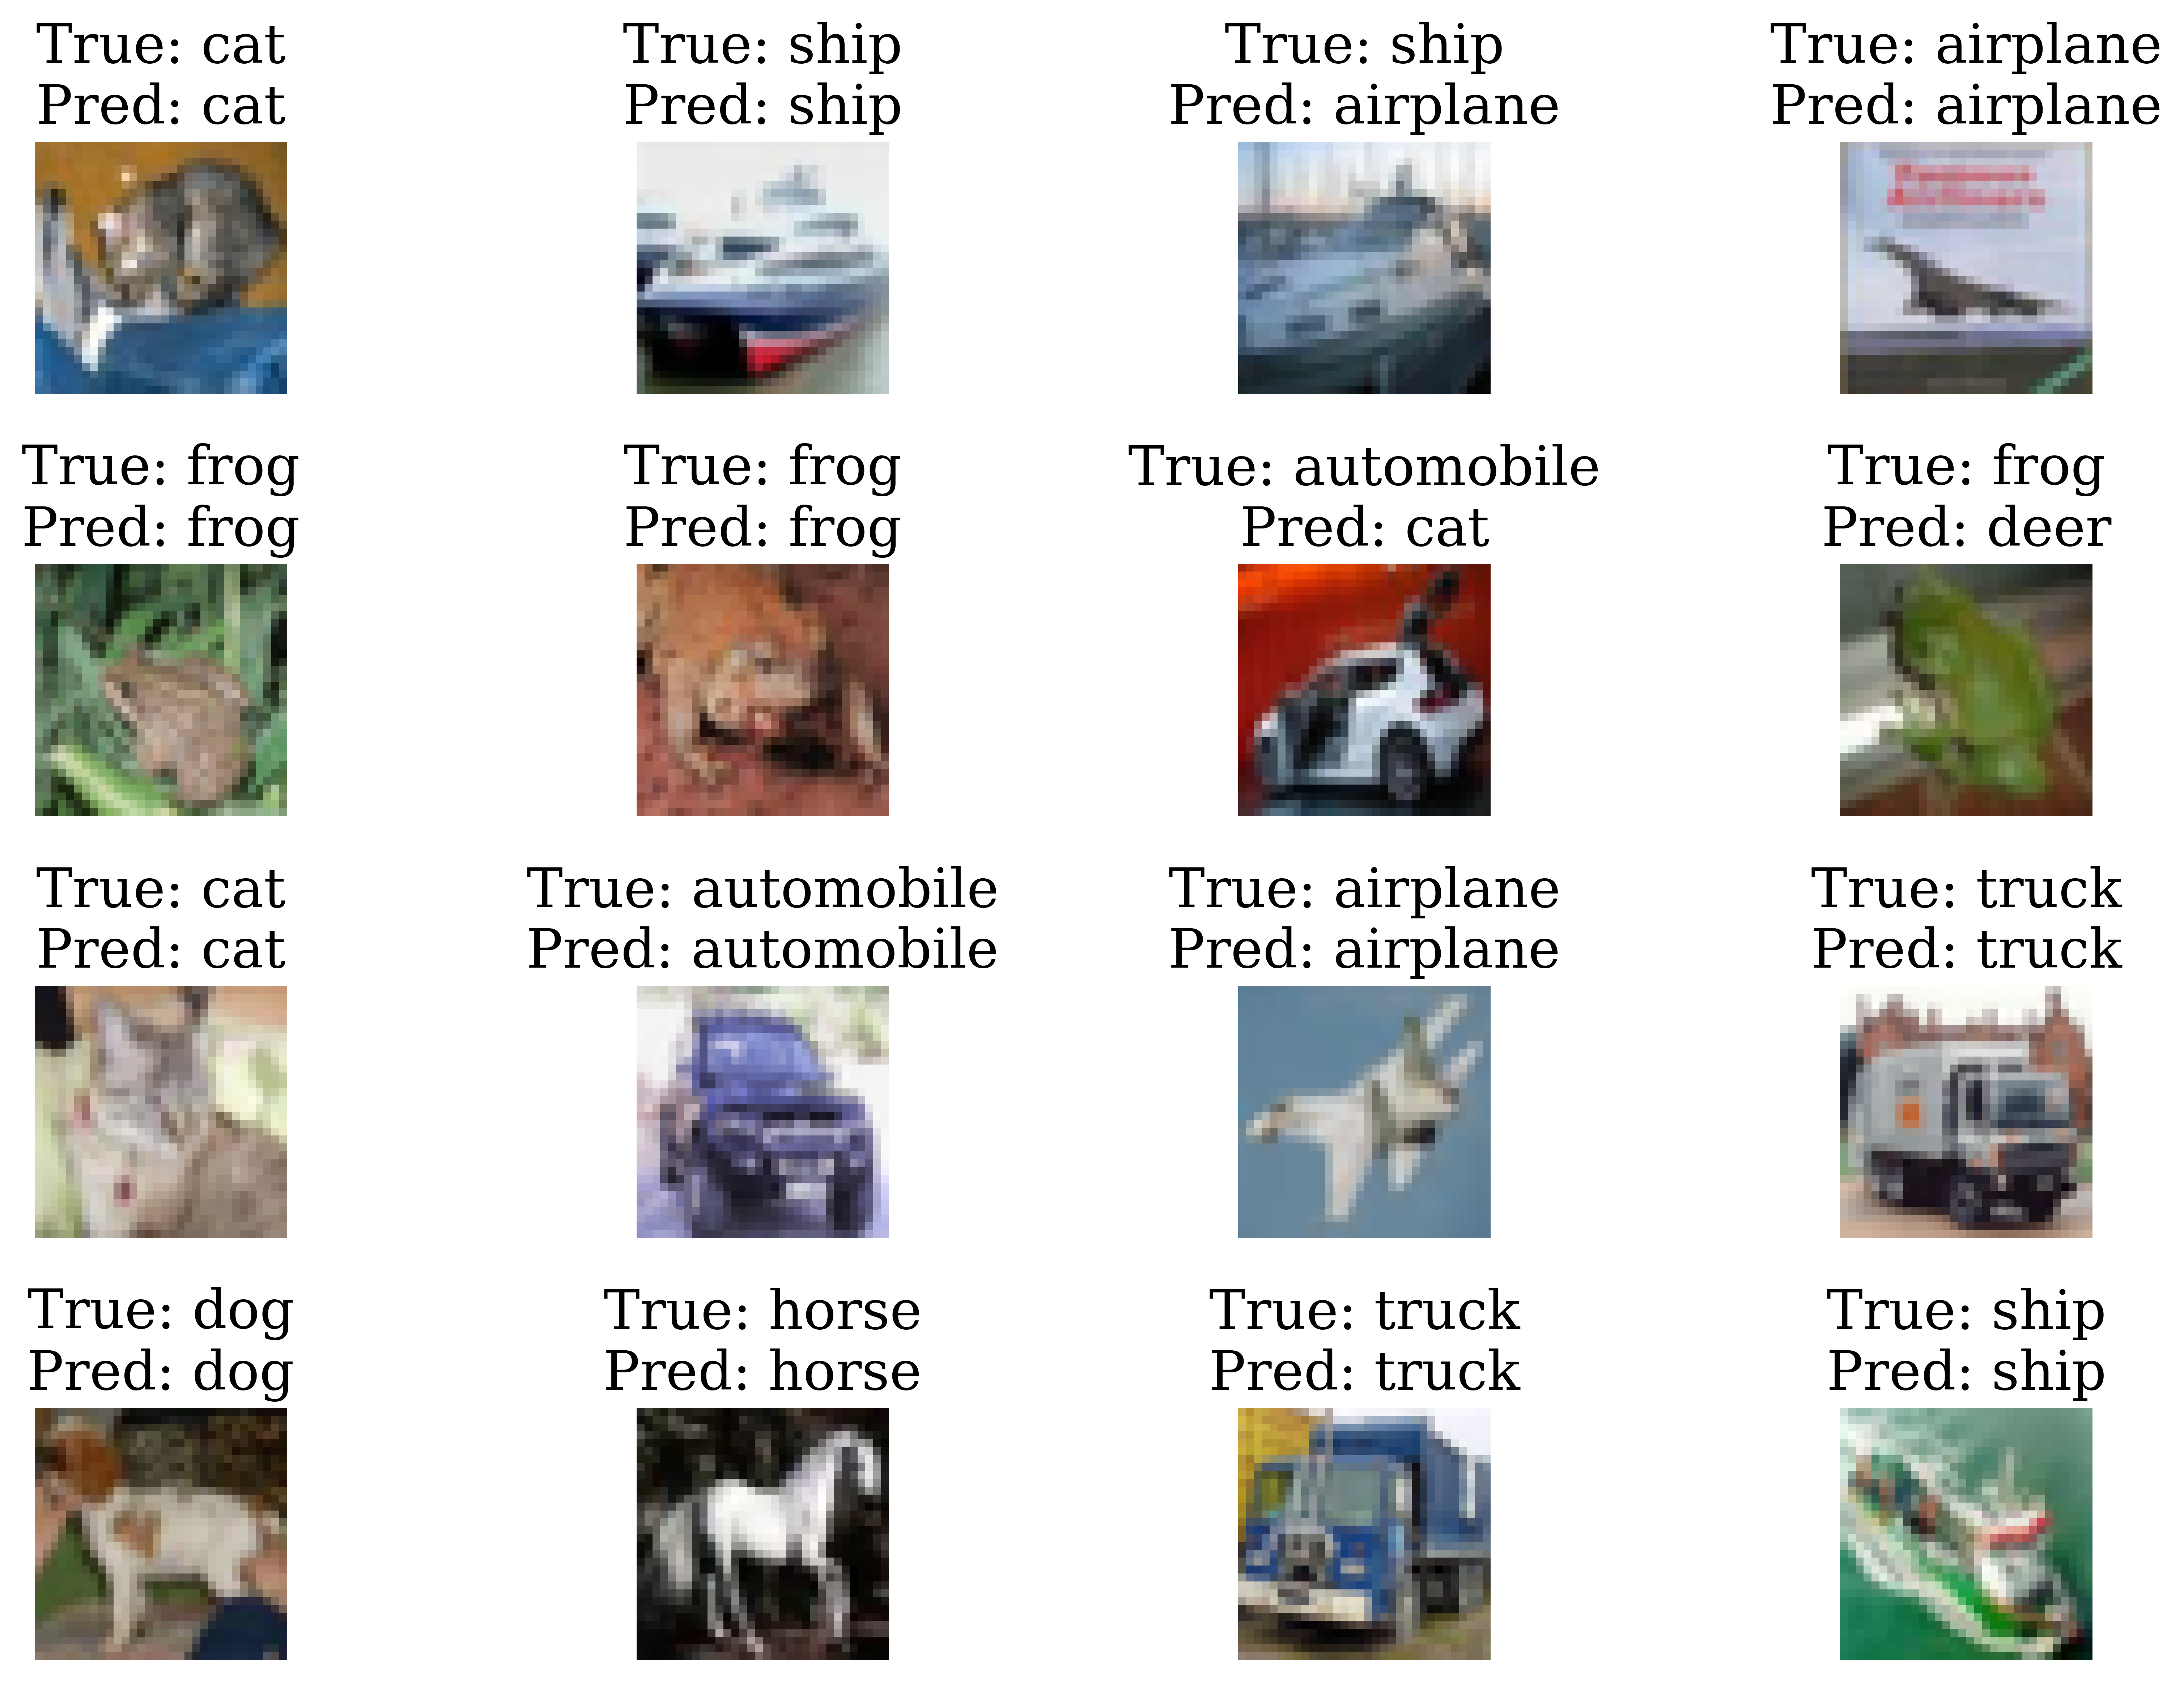

In [ ]:
plt.figure(figsize=(12, 8))

for i in range(16):

    plt.subplot(4, 4, i + 1)

    plt.imshow(x_test[i])

    true_label = class_names[y_true[i]]
    predicted_label = class_names[y_pred[i]]

    plt.title(
        f"True: {true_label}\nPred: {predicted_label}"
    )

    plt.axis("off")

plt.tight_layout()
plt.savefig(
    "predictions.eps",
    dpi=600,
    bbox_inches="tight"
)
plt.show()

In [ ]:
layer_outputs = []

layer_names = []

for layer in model.layers:
    if isinstance(layer, layers.Conv2D):
        layer_outputs.append(layer.output)
        layer_names.append(layer.name)

feature_map_model = tf.keras.Model(
    inputs=model.inputs,
    outputs=layer_outputs
)

image = x_test[0]

input_image = np.expand_dims(image, axis=0)

feature_maps = feature_map_model.predict(input_image)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step


conv2d_6
Feature map shape: (1, 32, 32, 32)


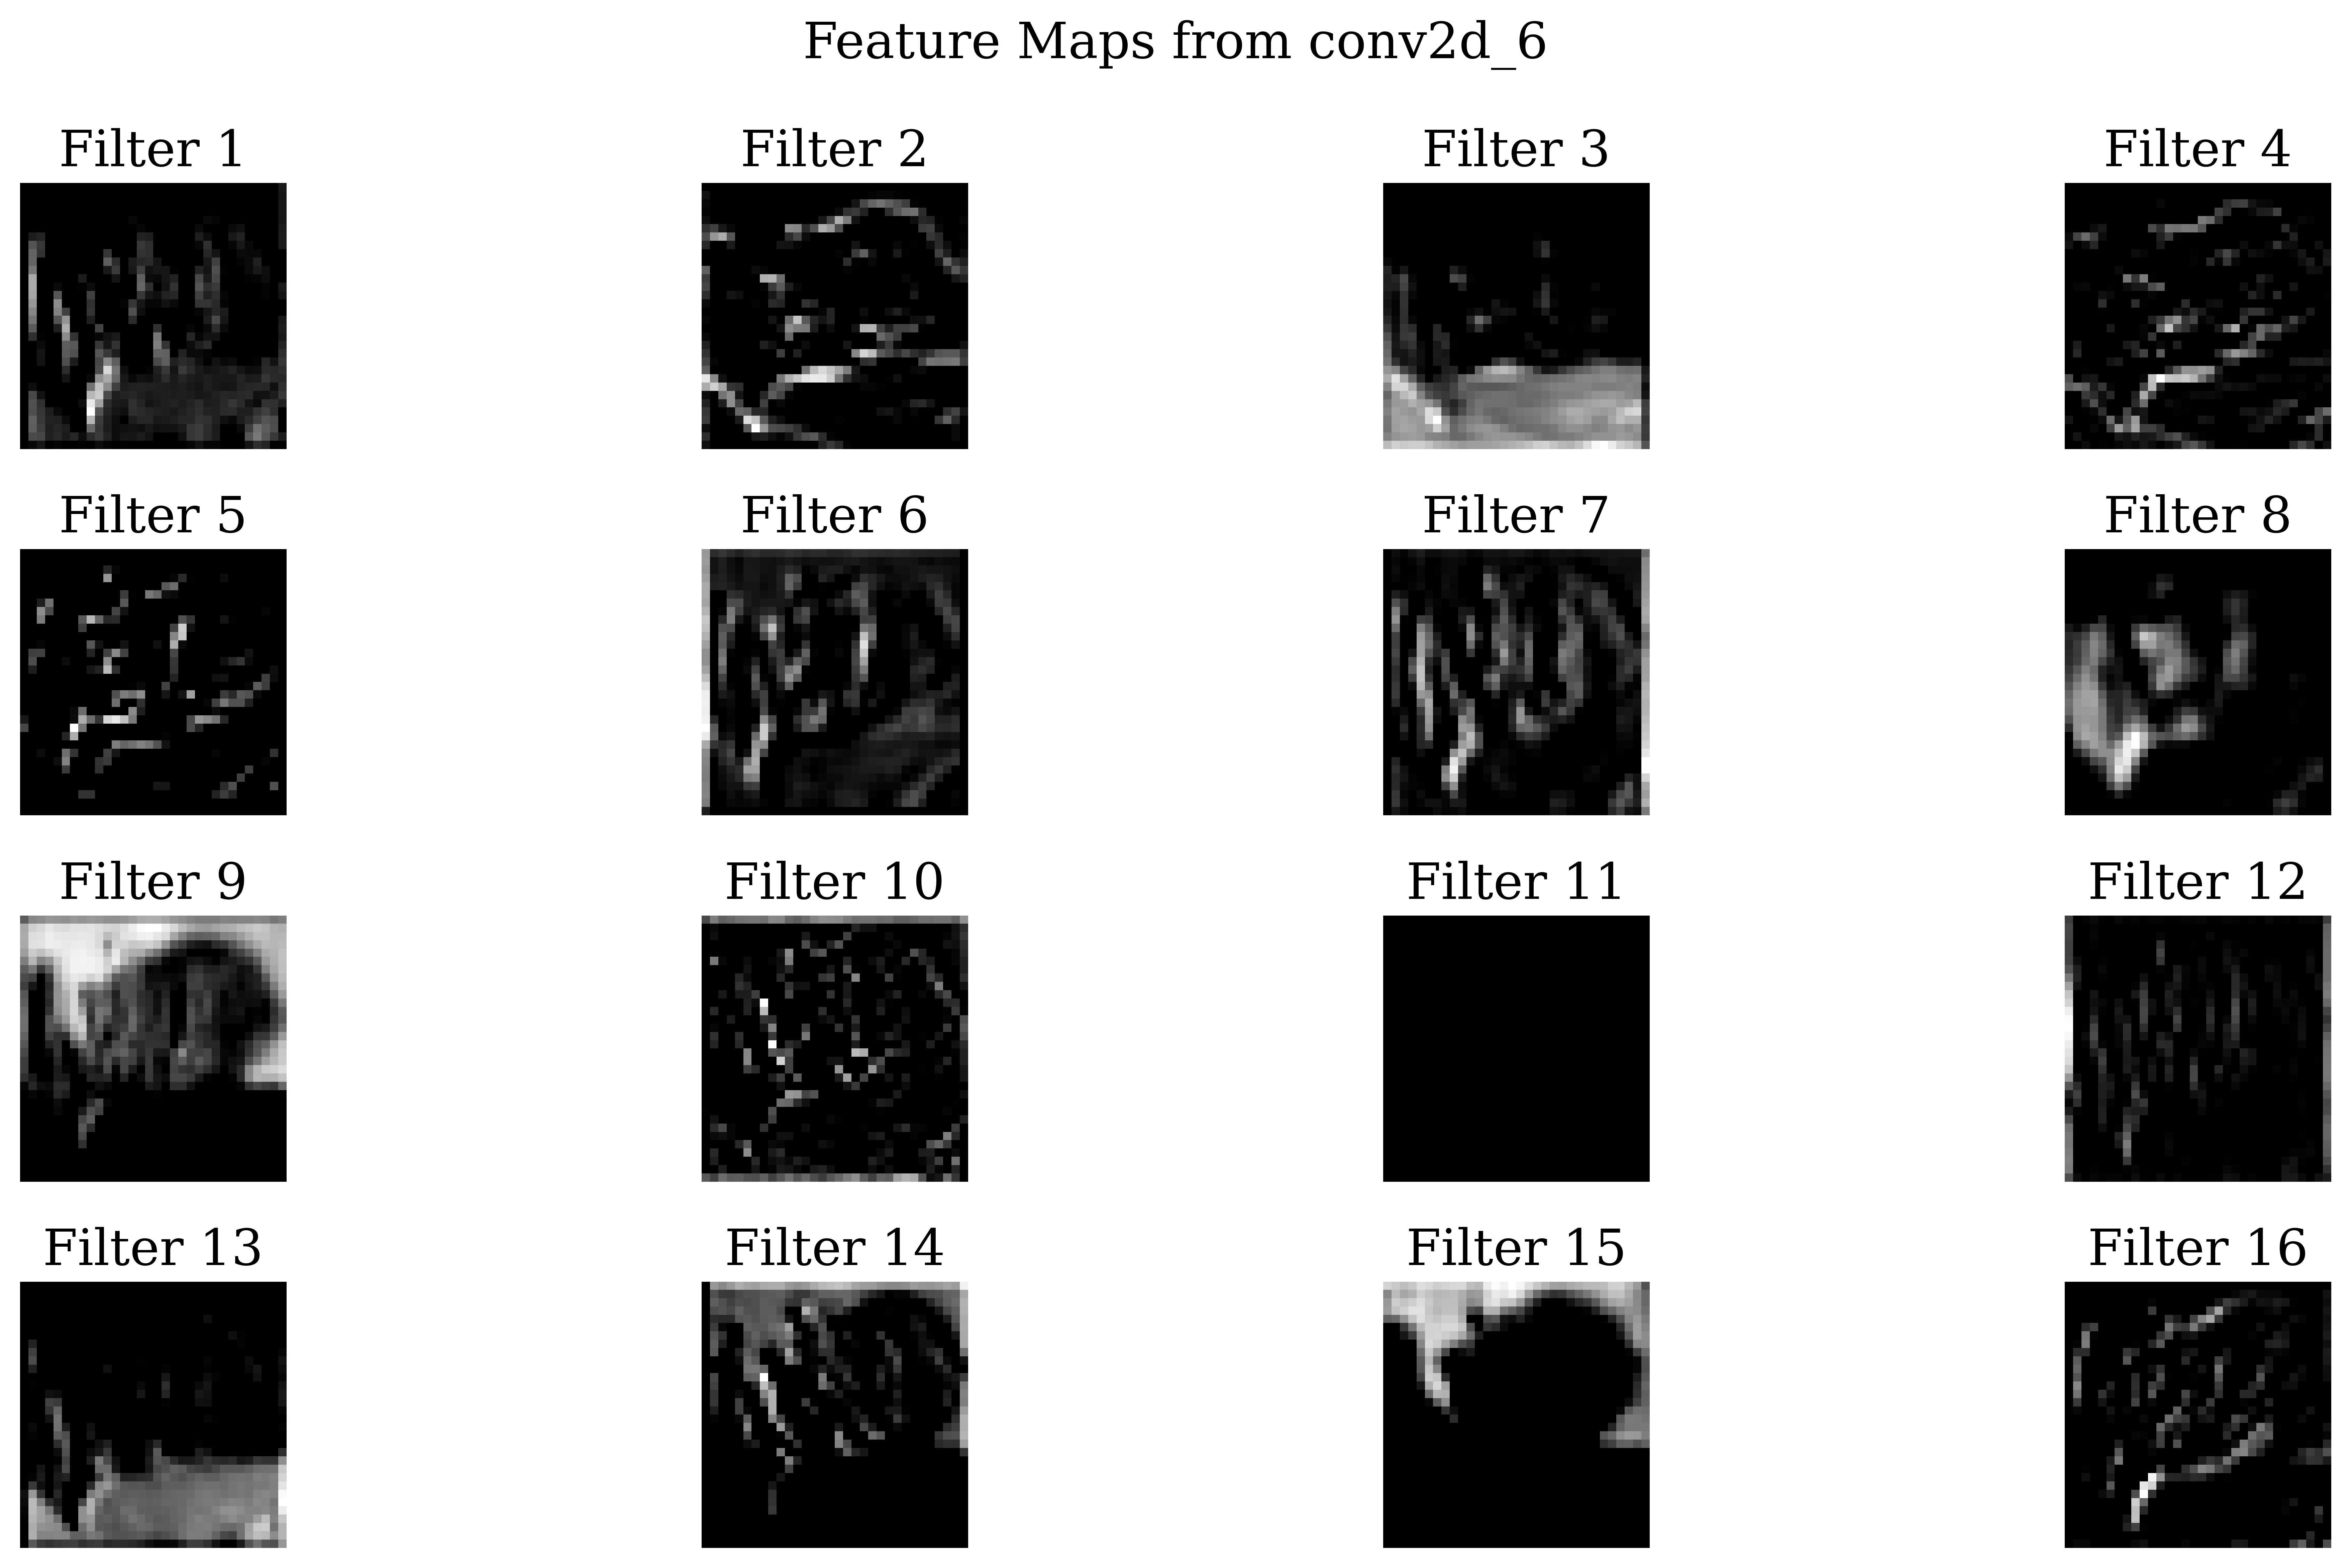

conv2d_7
Feature map shape: (1, 16, 16, 64)


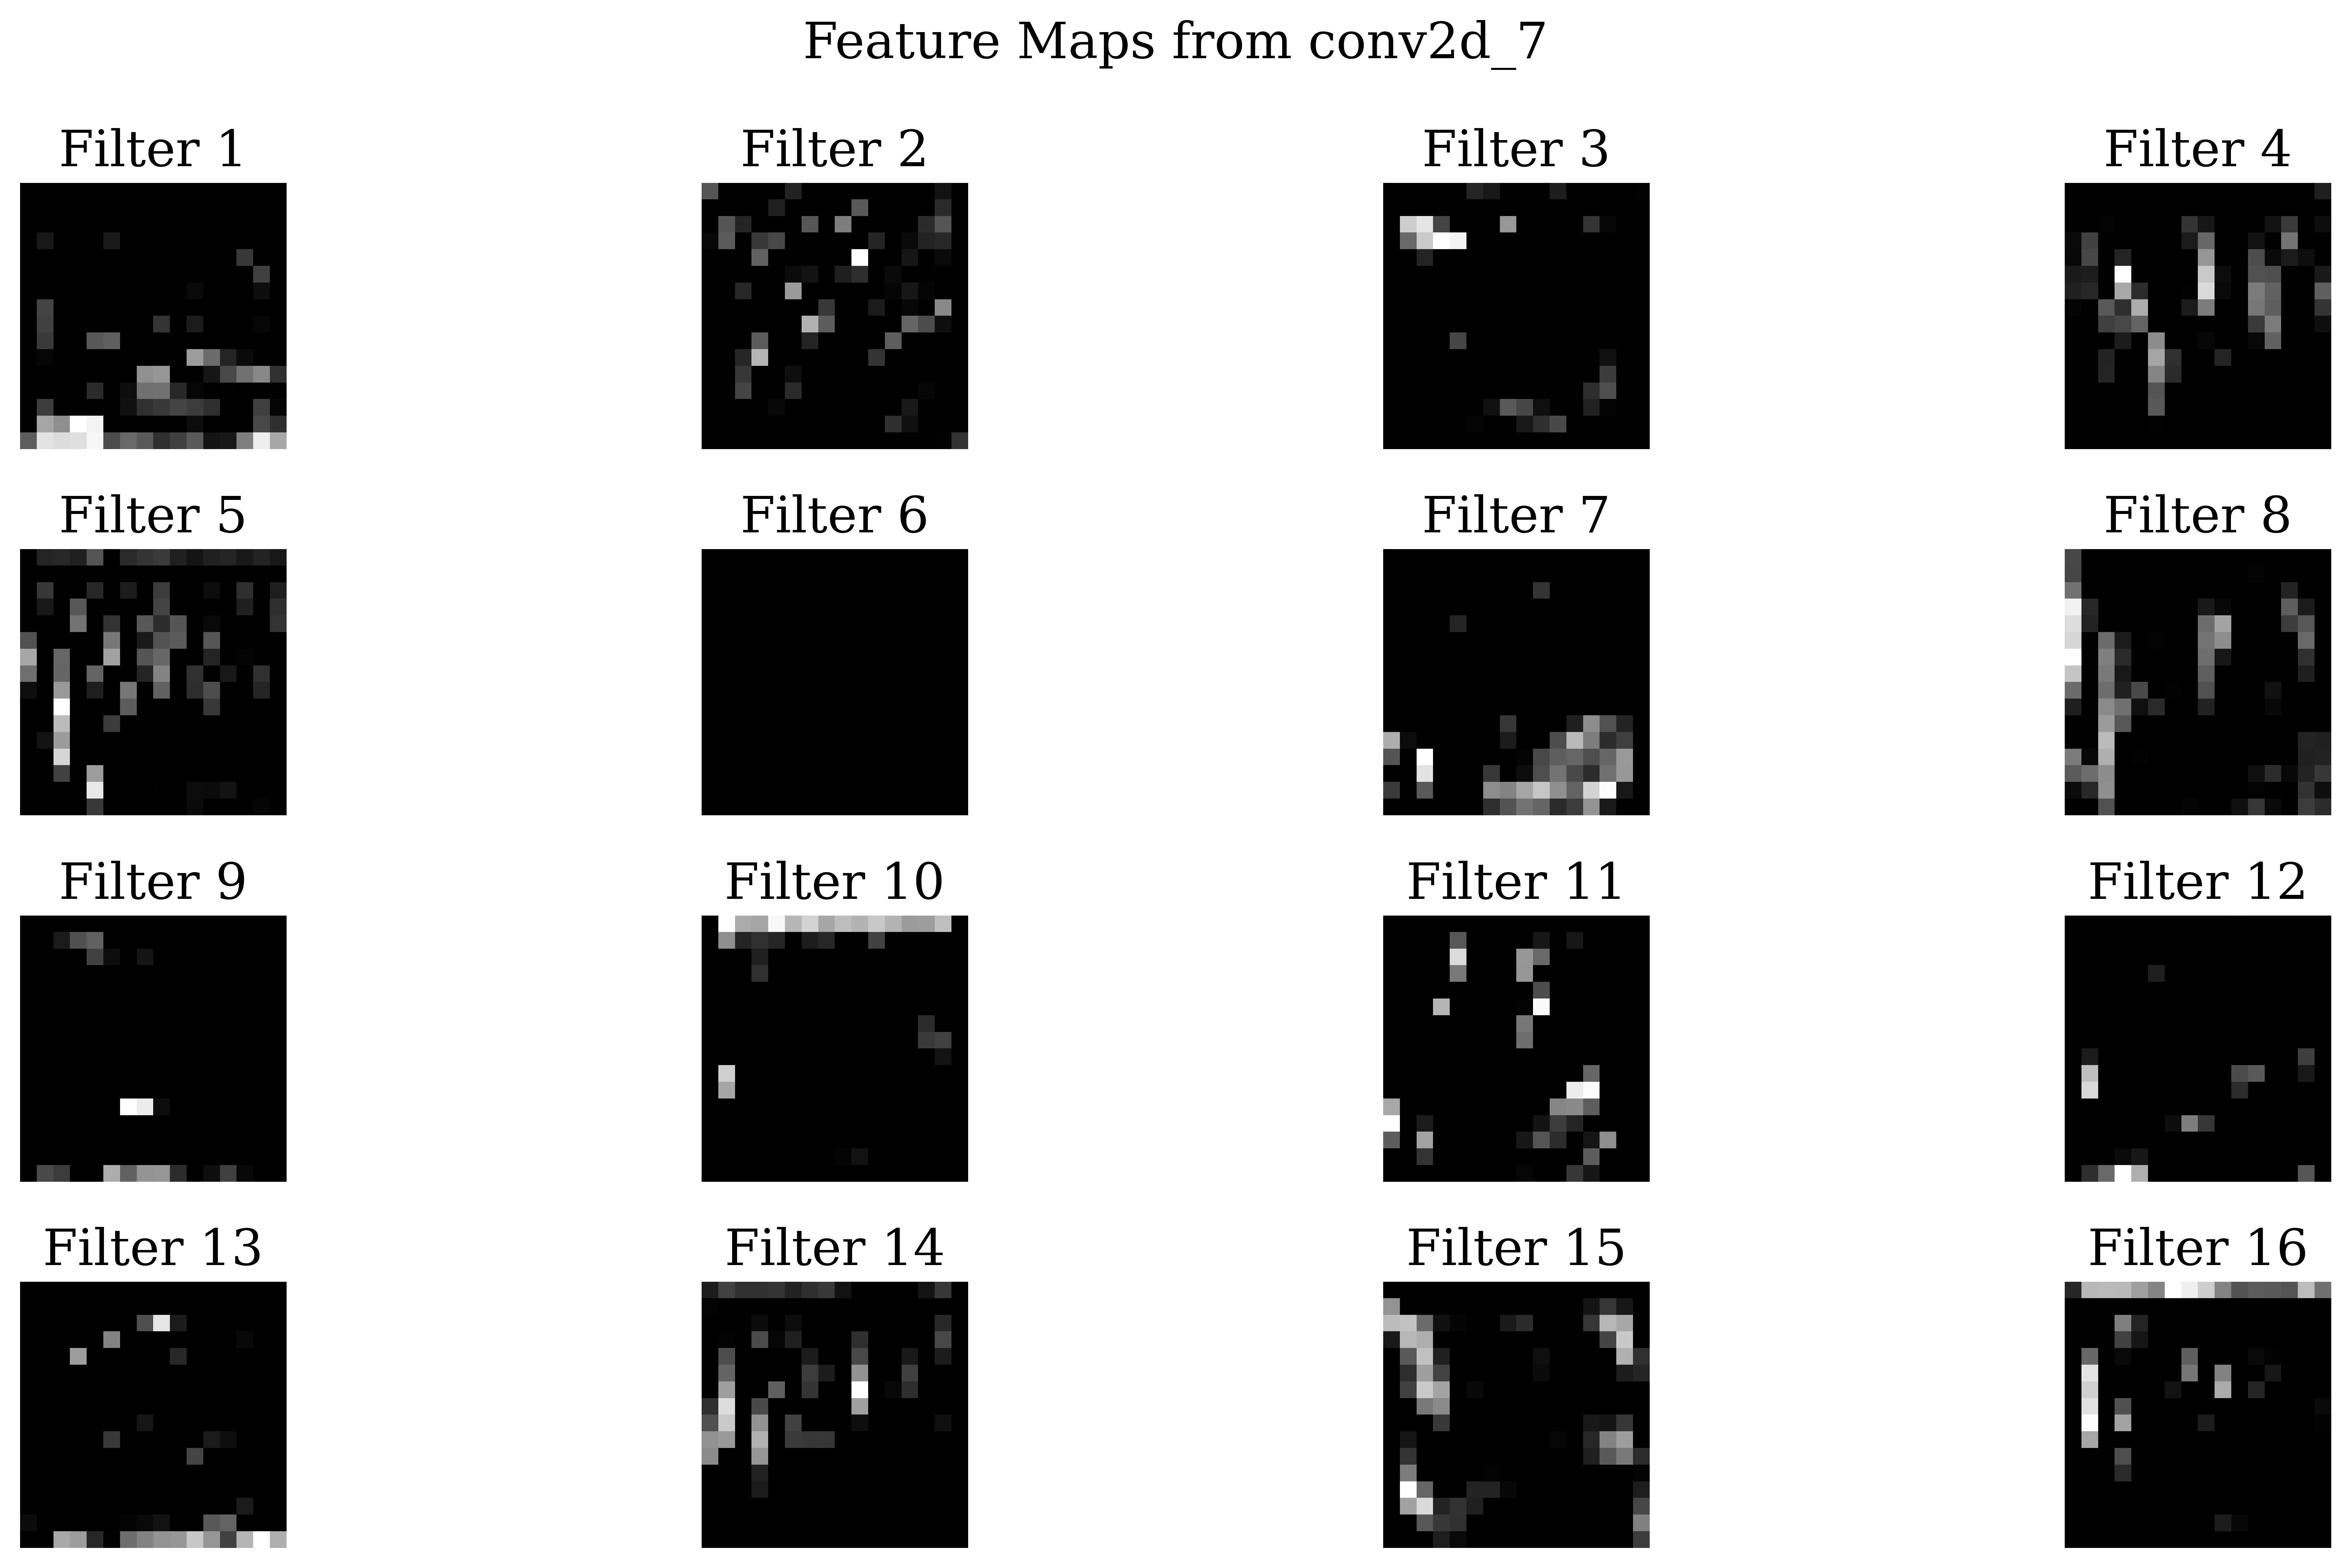

conv2d_8
Feature map shape: (1, 8, 8, 128)


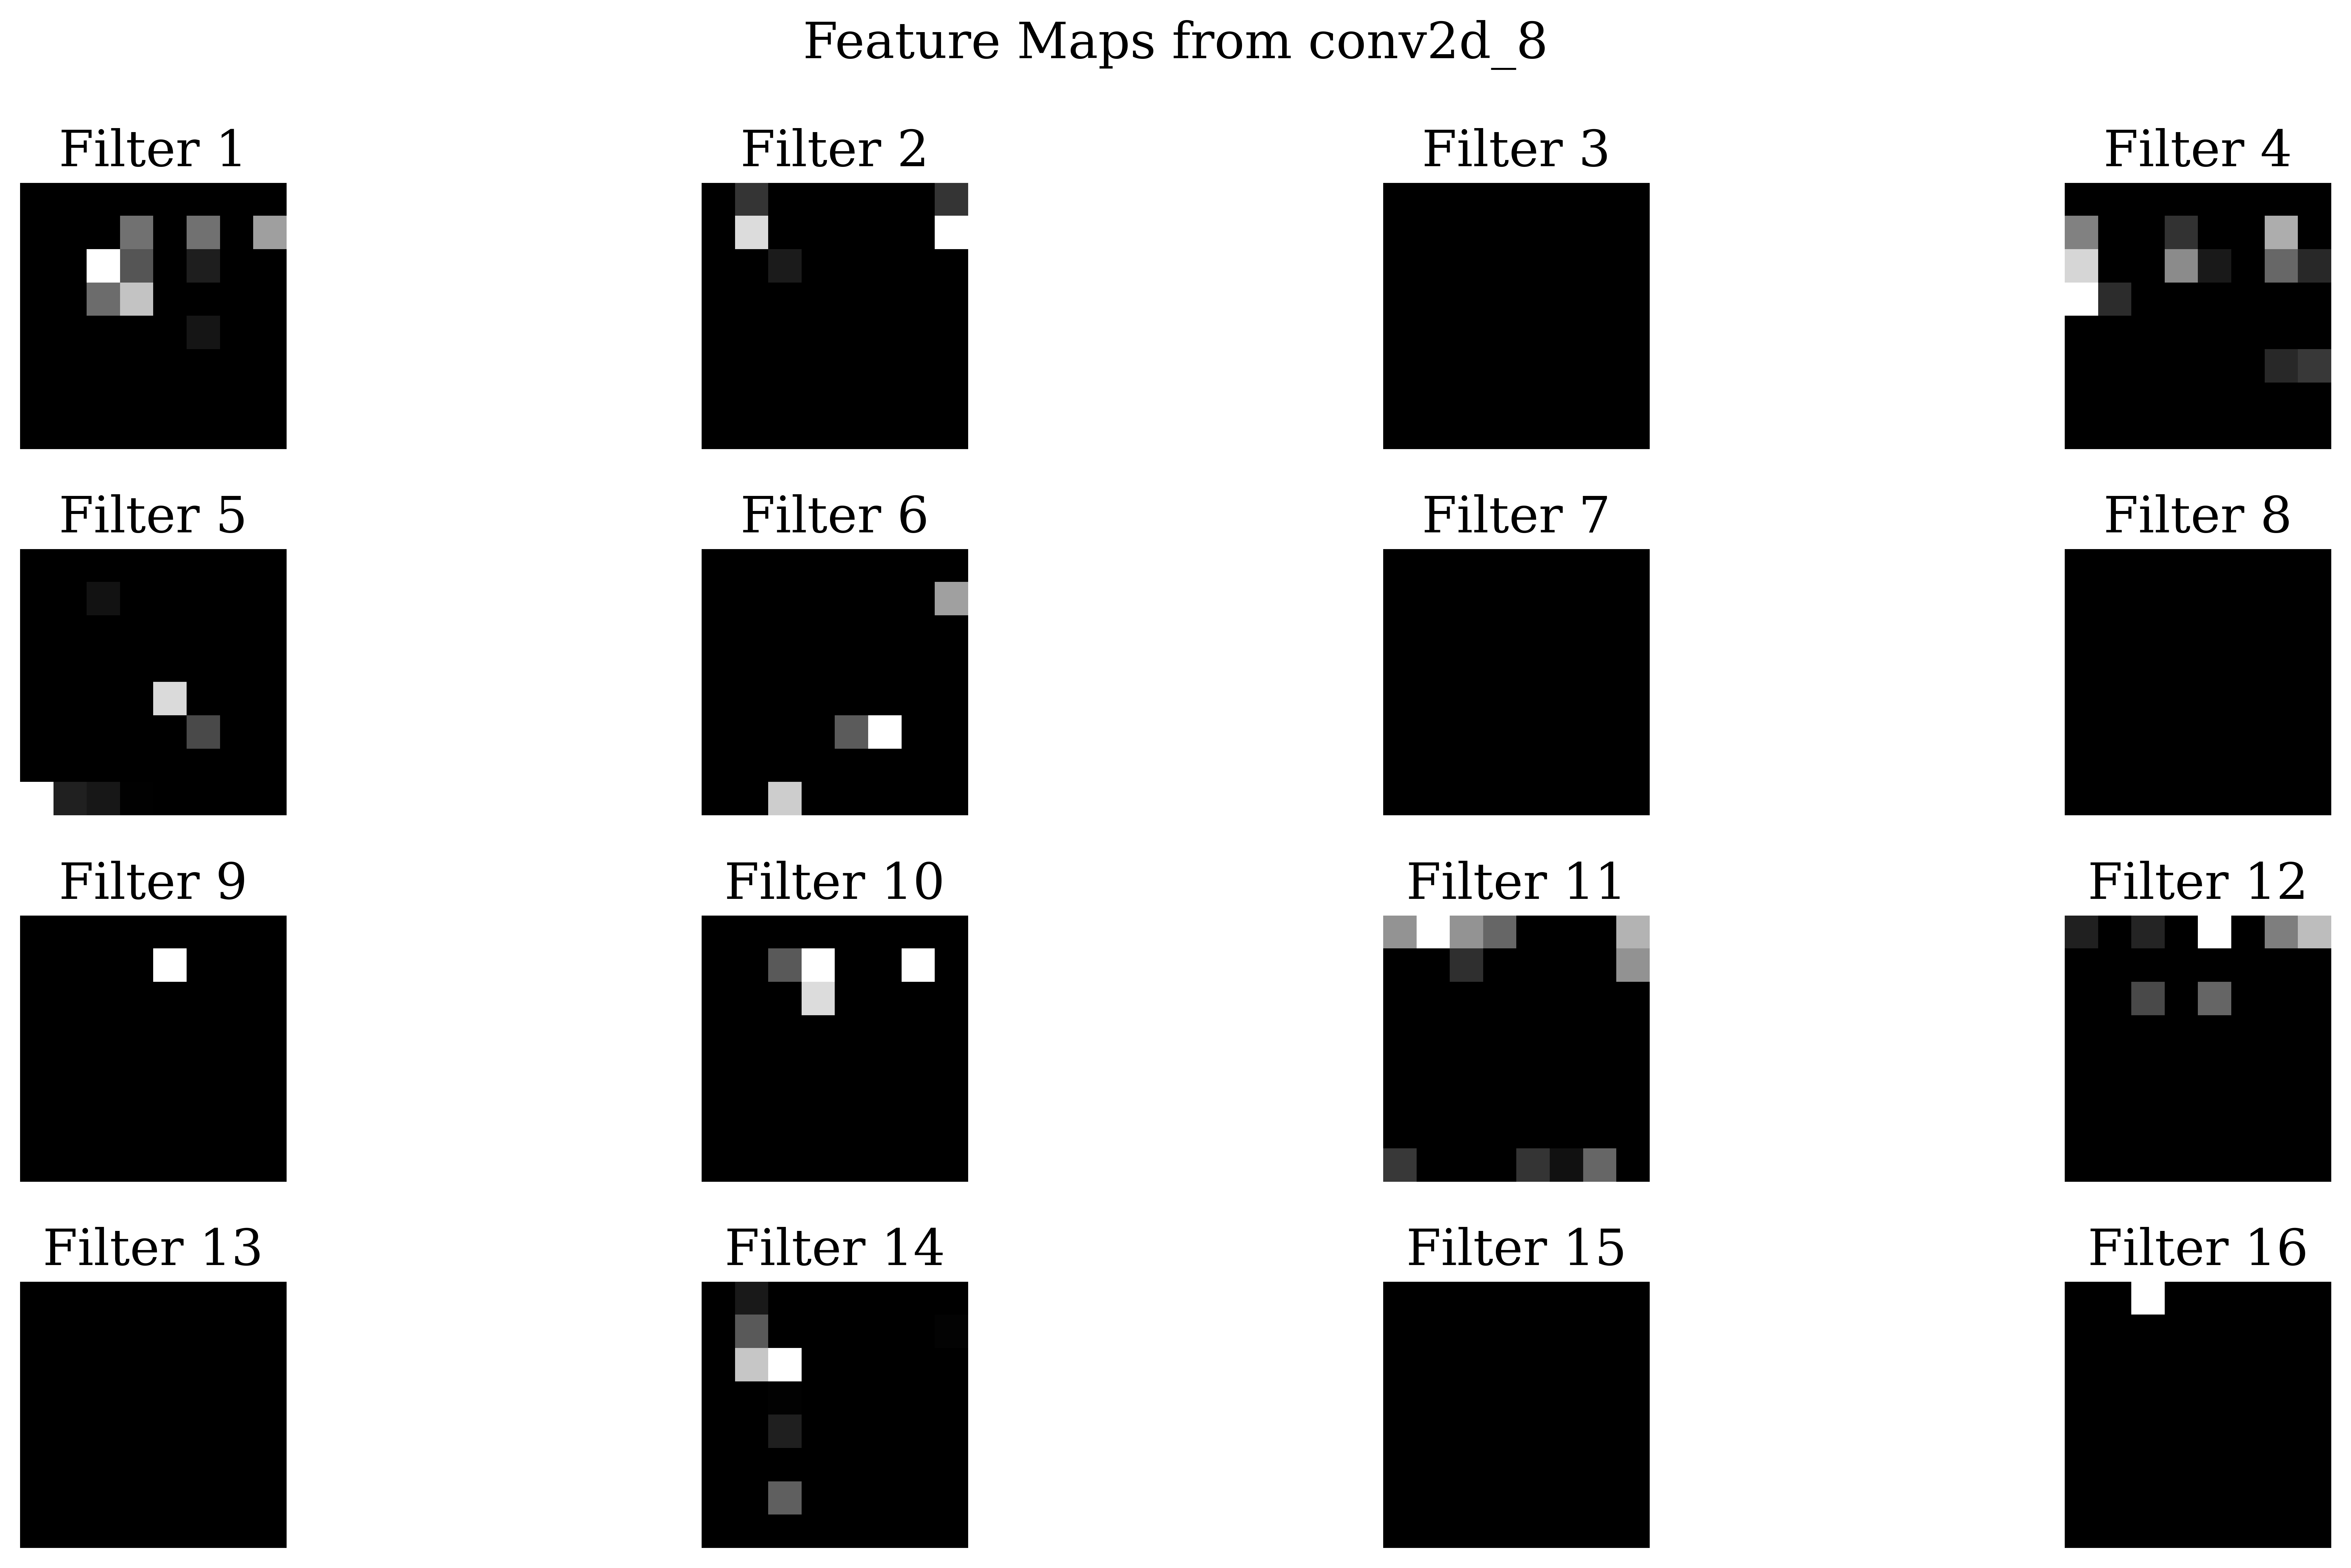

In [ ]:
for layer_name, feature_map in zip(layer_names, feature_maps):

    print(layer_name)
    print("Feature map shape:", feature_map.shape)

    plt.figure(figsize=(15, 8))

    num_filters = min(feature_map.shape[-1], 16)

    for i in range(num_filters):

        plt.subplot(4, 4, i + 1)

        plt.imshow(feature_map[0, :, :, i], cmap='gray')

        plt.title(f"Filter {i + 1}")

        plt.axis("off")

    plt.suptitle(f"Feature Maps from {layer_name}")

    plt.tight_layout()
    plt.savefig(
        "feature_map.eps",
        dpi=600,
        bbox_inches="tight"
    )
    plt.show()

In [ ]:
max_pool_model = models.Sequential([
    layers.Conv2D(
        32,
        (3, 3),
        activation='relu',
        padding='same',
        input_shape=(32, 32, 3)
    ),

    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
avg_pool_model = models.Sequential([
    layers.Conv2D(
        32,
        (3, 3),
        activation='relu',
        padding='same',
        input_shape=(32, 32, 3)
    ),

    layers.AveragePooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(10, activation='softmax')
])

In [ ]:
max_pool_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

avg_pool_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
max_history = max_pool_model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

avg_history = avg_pool_model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 50s 70ms/step - accuracy: 0.4490 - loss: 1.5652 - val_accuracy: 0.5300 - val_loss: 1.3602
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 43s 61ms/step - accuracy: 0.5585 - loss: 1.2649 - val_accuracy: 0.5908 - val_loss: 1.2034
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 75s 52ms/step - accuracy: 0.6008 - loss: 1.1522 - val_accuracy: 0.6022 - val_loss: 1.1584
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 40s 50ms/step - accuracy: 0.6284 - loss: 1.0746 - val_accuracy: 0.6138 - val_loss: 1.1213
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 35s 50ms/step - accuracy: 0.6478 - loss: 1.0227 - val_accuracy: 0.6318 - val_loss: 1.0832
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 36s 52ms/step - accuracy: 0.6658 - loss: 0.9741 - val_accuracy: 0.6288 - val_loss: 1.0970
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 37s 53ms/step - accuracy: 0.6791 - loss: 0.9376 - val_accuracy: 0.6440 - val_loss: 1.0440
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 35s 50ms/step - accuracy: 0.6893 - loss: 0.9029 - 

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    max_history.history['val_accuracy'],
    label='Max Pooling'
)

plt.plot(
    avg_history.history['val_accuracy'],
    label='Average Pooling'
)

plt.title("Max Pooling vs Average Pooling")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")

plt.legend()
plt.grid()
plt.savefig(
    "max_pooling_vs_avg_pooling.pdf",
    dpi=600,
    bbox_inches="tight"
)
plt.show()